In [1]:
# install piccard and piccard2
import sys
import os

sys.path.append(os.path.abspath('../src/piccard'))

# %pip install tscluster
# %pip install --upgrade geopandas
# %pip install yellowbrick
# %pip install --upgrade shapely

# install other dependencies, pip install first if needed
from tscluster.tsplot import tsplot
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import piccard2 as pc2

import warnings
warnings.filterwarnings('ignore')

C:\Users\ecorb\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import sys
import os

sys.path.append(os.path.abspath('../../../ppandas/ppandas'))
from p_frame import PDataFrame

In [3]:
housing_data_06 = gpd.read_file("piccard2_testing_data/housing_data_06.geojson")
housing_data_06.rename(columns={'v_CA06_102: Owned': 'num_owned',
                                'v_CA06_103: Rented': 'num_rented',
                                'v_CA06_2054: Average value of dwelling $': 'avg_value',
                                'v_CA06_2057: Owner households spending 30% to 99% of household income on owner\'s major payments': 'owner_30_or_more',
                                'v_CA06_2053: Owner-occupied private non-farm, non-reserve dwellings': 'total_owner',
                                'v_CA06_2052: Tenant-occupied households spending from 30% to 99% of household income on gross rent': 'renter_30_or_more',
                                'v_CA06_2049: Tenant-occupied private non-farm, non-reserve dwellings': 'total_renter',
                                'v_CA06_2050: Average gross rent $': 'avg_rent'
                                }, inplace=True)
housing_data_06['pct_owner_30_or_more'] = (housing_data_06['owner_30_or_more'] / housing_data_06['total_owner']) * 100
housing_data_06['pct_renter_30_or_more'] = (housing_data_06['renter_30_or_more'] / housing_data_06['total_renter']) * 100
housing_data_06 = housing_data_06.drop(['owner_30_or_more', 'total_owner', 'renter_30_or_more', 'total_renter'], axis=1)

In [4]:
housing_data_11 = gpd.read_file("piccard2_testing_data/housing_data_11.geojson")
housing_data_11.rename(columns={'v_CA11N_2253: Owner': 'num_owned',
                                'v_CA11N_2254: Renter': 'num_rented',
                                'v_CA11N_2287: Average value of dwellings ($)': 'avg_value',
                                'v_CA11N_2283: % of owner households spending 30% or more of household total income on shelter costs': 'pct_owner_30_or_more',
                                'v_CA11N_2290: % of tenant households spending 30% or more of household total income on shelter costs': 'pct_renter_30_or_more',
                                'v_CA11N_2292: Average monthly shelter costs for rented dwellings ($)': 'avg_rent'
                                }, inplace=True)

In [5]:
housing_data_16 = gpd.read_file("piccard2_testing_data/housing_data_16.geojson")
housing_data_16.rename(columns={'v_CA16_4837: Owner': 'num_owned',
                                'v_CA16_4838: Renter': 'num_rented',
                                'v_CA16_4896: Average value of dwellings ($)': 'avg_value',
                                'v_CA16_4892: % of owner households spending 30% or more of its income on shelter costs': 'pct_owner_30_or_more',
                                'v_CA16_4899: % of tenant households spending 30% or more of its income on shelter costs': 'pct_renter_30_or_more',
                                'v_CA16_4901: Average monthly shelter costs for rented dwellings ($)': 'avg_rent'
                                }, inplace=True)

In [6]:
housing_data_21 = gpd.read_file("piccard2_testing_data/housing_data_21.geojson")
housing_data_21.rename(columns={'v_CA21_4238: Owner': 'num_owned',
                                'v_CA21_4239: Renter': 'num_rented',
                                'v_CA21_4312: Average value of dwellings ($) (60)': 'avg_value',
                                'v_CA21_4318: Average monthly shelter costs for rented dwellings ($) (59)': 'avg_rent',
                                'v_CA21_4307: % of owner households spending 30% or more of its income on shelter costs (55)': 'pct_renter_30_or_more',
                                'v_CA21_4315: % of tenant households spending 30% or more of its income on shelter costs (55)': 'pct_owner_30_or_more'
                                }, inplace=True)

In [7]:
census_dfs = [housing_data_06, housing_data_11, housing_data_16, housing_data_21]
years = ['2006', '2011', '2016', '2021']
G = pc2.create_network(census_dfs, years, 'GeoUID')
network_table = pc2.create_network_table(census_dfs, years, 'GeoUID')

Preprocessing complete
CT_CONTAINMENT: total rows = 4469 | parallel = False
All nodes found
All attributes found
Graph created
Preprocessing complete
CT_CONTAINMENT: total rows = 4469 | parallel = False
All nodes found
All possible paths through the graph found
All attributes found
Table created


In [12]:
pc2.plot_subnetwork(network_table, G, paths_to_show=[14, 15, 16])

In [13]:
pc2.plot_subnetwork(network_table, G)

In [14]:
pc2.plot_num_areas(network_table)

In [9]:
arr, label_dict, network_table = pc2.clustering_prep(network_table, 'GeoUID', [
    'num_owned_2006', 'avg_value_2006', 'pct_owner_30_or_more_2006',
    'num_owned_2011', 'avg_value_2011', 'pct_owner_30_or_more_2011',
    'num_owned_2016', 'avg_value_2016', 'pct_owner_30_or_more_2016',
    'num_owned_2021', 'avg_value_2021', 'pct_owner_30_or_more_2021'])

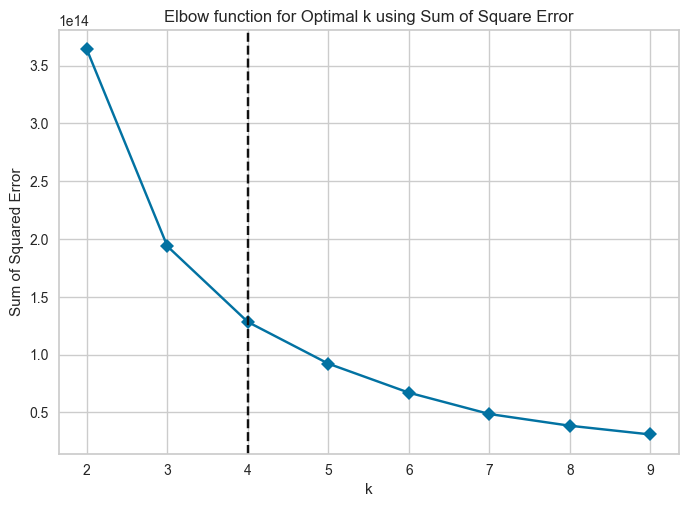

In [10]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

reshaped_arr = arr.reshape(arr.shape[0] * arr.shape[1], arr.shape[2])  # (N*T, F)

model = KMeans(random_state=4,n_init=10)
visualizer = KElbowVisualizer(model, k=(2,10),timings=False, ax=plt.gca())
visualizer.fit(reshaped_arr)       # Fit data to visualizer
plt.title('Elbow function for Optimal k using Sum of Square Error')
plt.xlabel('k')
plt.ylabel('Sum of Squared Error')
plt.show()

In [11]:
tsc = pc2.cluster(network_table, G, 'GeoUID', 4, arr=arr, label_dict=label_dict)

Initialization with kmeans++, Sum of Distance: 103011460141591.1250, Max Distance: 1680000.0700
Iteration 0, Sum of distance: 92509800590596.4375, Max distance: 1532500.0438, Number of change: 254
Iteration 5, Sum of distance: 84839217378036.8906, Max distance: 1532500.0438, Number of change: 43
Iteration 10, Sum of distance: 84275348975303.7031, Max distance: 1532500.0438, Number of change: 13
Iteration 15, Sum of distance: 84226652831098.0156, Max distance: 1532500.0438, Number of change: 0
Iteration 20, Sum of distance: 84226652831098.0156, Max distance: 1532500.0438, Number of change: 0
Converged at iteration 21, Sum of distance: 84226652831098.0156, Max distance: 1532500.0438
1232
1232
1232
1232
1232
1232
1232
1232


In [16]:
figs = pc2.plot_clusters_scatter(
    tsc=tsc,
    network_table=network_table,
    label_dict=label_dict,
    arr=arr,
    dynamic_paths_only = True,
)

for fig in figs:
    fig.show()